# Rock Glacier Dataset: Pre-Training Data Validation & EDA

This notebook validates the alignment between our 12-band Earth Engine features and the binary masks, and checks data quality before deep learning training.

**Dataset Specs:**
- CRS: `EPSG:32645` (UTM Zone 45N)
- Resolution: 10m/pixel
- Features: 12-band GeoTIFF (Float32/Float64)
- Masks: 1-band GeoTIFF (Binary: 0=Background, 1=Rock Glacier)

**12-Band Feature Mapping:**

| Band (1-indexed) | Name        | Description                     |
|:-----------------:|:------------|:--------------------------------|
| 1                | B2          | Blue                            |
| 2                | B3          | Green                           |
| 3                | B4          | Red                             |
| 4                | B8          | Near-Infrared (NIR)             |
| 5                | B11         | SWIR-1                          |
| 6                | B12         | SWIR-2                          |
| 7                | NDVI        | Vegetation Index                |
| 8                | NDWI        | Water Index                     |
| 9                | NDSI        | Snow Index                      |
| 10               | Elevation   | Copernicus DEM GLO-30 (meters)  |
| 11               | Slope       | Terrain slope (degrees)         |
| 12               | Aspect      | Terrain aspect (degrees)        |

## 1. Environment Setup & Initialization

In [1]:
import os
import glob
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from rasterio.plot import show
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Directory Configuration ──────────────────────────────────────────────────
FEATURE_DIR  = r'D:\RockGlacier_Project\features'
MASK_DIR     = r'D:\RockGlacier_Project\masks'
POLYGON_DIR  = r'D:\RockGlacier_Project\EDA\individual_polygons'

# ── Band name lookup (1-indexed, matching rasterio .read(band)) ───────────────
BAND_NAMES = {
    1:  'B2 (Blue)',
    2:  'B3 (Green)',
    3:  'B4 (Red)',
    4:  'B8 (NIR)',
    5:  'B11 (SWIR-1)',
    6:  'B12 (SWIR-2)',
    7:  'NDVI',
    8:  'NDWI',
    9:  'NDSI',
    10: 'Elevation (m)',
    11: 'Slope (°)',
    12: 'Aspect (°)',
}

# ── Discover files ────────────────────────────────────────────────────────────
feature_files = sorted(glob.glob(os.path.join(FEATURE_DIR, 'feature_*.tif')))
mask_files    = sorted(glob.glob(os.path.join(MASK_DIR,    'mask_*.tif')))

print(f"Found {len(feature_files)} feature files.")
print(f"Found {len(mask_files)} mask files.")

# ── Helper: extract zero-padded index from filename ───────────────────────────
def get_idx(filepath):
    """Return the XXXX index string from 'feature_XXXX.tif' or 'mask_XXXX.tif'."""
    return os.path.basename(filepath).split('_')[1].split('.')[0]

# Build a lookup: idx -> mask_path
mask_lookup = {get_idx(p): p for p in mask_files}

Found 607 feature files.
Found 610 mask files.


## 2. Spatial Alignment Validation

Checks every `feature_XXXX.tif` / `mask_XXXX.tif` pair for identical `.shape`, `.crs`, and `.transform`.
A mismatch here will cause silent tensor corruption in a PyTorch `Dataset` — catch it now.

In [2]:
def check_alignment(feature_path, mask_path):
    """
    Validate spatial alignment between a feature tile and its corresponding mask.
    Returns (is_aligned: bool, details: dict).
    """
    with rasterio.open(feature_path) as f_src, rasterio.open(mask_path) as m_src:
        details = {
            'feature_shape'    : f_src.shape,
            'mask_shape'       : m_src.shape,
            'feature_crs'      : str(f_src.crs),
            'mask_crs'         : str(m_src.crs),
            'shape_match'      : f_src.shape     == m_src.shape,
            'crs_match'        : f_src.crs        == m_src.crs,
            'transform_match'  : f_src.transform  == m_src.transform,
            'feature_bands'    : f_src.count,
            'mask_bands'       : m_src.count,
        }
        is_aligned = details['shape_match'] and details['crs_match'] and details['transform_match']
    return is_aligned, details


print("Validating spatial alignment across all downloaded pairs...\n")

mismatches   = []
missing_masks = []
aligned_count = 0

for f_path in feature_files:
    idx    = get_idx(f_path)
    m_path = mask_lookup.get(idx)

    if m_path is None:
        missing_masks.append(os.path.basename(f_path))
        continue

    is_ok, details = check_alignment(f_path, m_path)
    if is_ok:
        aligned_count += 1
    else:
        mismatches.append({'file': f'feature_{idx}.tif', **details})

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"✅  Aligned pairs    : {aligned_count}")
print(f"❌  Mismatched pairs : {len(mismatches)}")
print(f"⚠️  Missing masks    : {len(missing_masks)}")

if missing_masks:
    print("\nFiles with no corresponding mask:")
    for fname in missing_masks:
        print(f"  • {fname}")

if mismatches:
    print("\nMismatch details:")
    df_mismatch = pd.DataFrame(mismatches)
    display(df_mismatch)
else:
    print("\n✅  ALL feature/mask pairs are perfectly aligned — safe to build PyTorch Dataset.")

Validating spatial alignment across all downloaded pairs...

✅  Aligned pairs    : 0
❌  Mismatched pairs : 607
⚠️  Missing masks    : 0

Mismatch details:


,file,feature_shape,mask_shape,feature_crs,mask_crs,shape_match,crs_match,transform_match,feature_bands,mask_bands
0,feature_0000.tif,"(95, 84)","(92, 81)",EPSG:32645,EPSG:32645,False,True,False,12,1
1,feature_0001.tif,"(87, 137)","(83, 134)",EPSG:32645,EPSG:32645,False,True,False,12,1
2,feature_0002.tif,"(56, 52)","(53, 49)",EPSG:32645,EPSG:32645,False,True,False,12,1
3,feature_0003.tif,"(74, 76)","(72, 73)",EPSG:32645,EPSG:32645,False,True,False,12,1
4,feature_0004.tif,"(140, 137)","(136, 133)",EPSG:32645,EPSG:32645,False,True,False,12,1
...,...,...,...,...,...,...,...,...,...,...
602,feature_0620.tif,"(62, 61)","(59, 58)",EPSG:32645,EPSG:32645,False,True,False,12,1
603,feature_0621.tif,"(62, 67)","(59, 64)",EPSG:32645,EPSG:32645,False,True,False,12,1
604,feature_0622.tif,"(53, 65)","(50, 62)",EPSG:32645,EPSG:32645,False,True,False,12,1
605,feature_0623.tif,"(71, 64)","(68, 61)",EPSG:32645,EPSG:32645,False,True,False,12,1


## 3. Dataset Metadata Summary

Quick scan of tile dimensions, dtype, pixel sizes and number of bands — useful for verifying consistent chip sizes.

In [3]:
records = []
for f_path in feature_files:
    with rasterio.open(f_path) as src:
        records.append({
            'file'        : os.path.basename(f_path),
            'height'      : src.height,
            'width'       : src.width,
            'bands'       : src.count,
            'dtype'       : src.dtypes[0],
            'res_x'       : round(src.res[0], 4),
            'res_y'       : round(src.res[1], 4),
            'crs'         : str(src.crs),
        })

df_meta = pd.DataFrame(records)
print("=== Feature Tile Metadata Summary ===")
print(df_meta.describe())

# Check for unexpected shapes
print("\nUnique tile shapes (H × W):")
print(df_meta.groupby(['height', 'width']).size().reset_index(name='count').to_string(index=False))

print("\nUnique dtypes:", df_meta['dtype'].unique())
print("Unique CRS:   ", df_meta['crs'].unique())

=== Feature Tile Metadata Summary ===
           height       width  bands  res_x  res_y
count  607.000000  607.000000  607.0  607.0  607.0
mean    86.682043   89.031301   12.0   10.0   10.0
std     30.378732   34.119050    0.0    0.0    0.0
min     49.000000   49.000000   12.0   10.0   10.0
25%     66.000000   67.000000   12.0   10.0   10.0
50%     78.000000   78.000000   12.0   10.0   10.0
75%     98.000000  102.000000   12.0   10.0   10.0
max    296.000000  332.000000   12.0   10.0   10.0

Unique tile shapes (H × W):
 height  width  count
     49     53      1
     50     54      1
     51     57      1
     52     56      1
     52     58      1
     52     61      1
     52     66      1
     52     75      1
     53     52      1
     53     53      1
     53     54      1
     53     55      1
     53     56      1
     53     60      1
     53     64      1
     53     65      1
     54     57      1
     54     64      1
     54     65      1
     55     52      1
     55     

## 4. Visual Overlay Inspection

Three-panel figure for any sample index:
1. **True Color RGB** (B4/B3/B2) with red polygon overlay
2. **Ground Truth Binary Mask**
3. **Derived Feature Heatmap** (NDVI by default — change `HEATMAP_BAND` as needed)

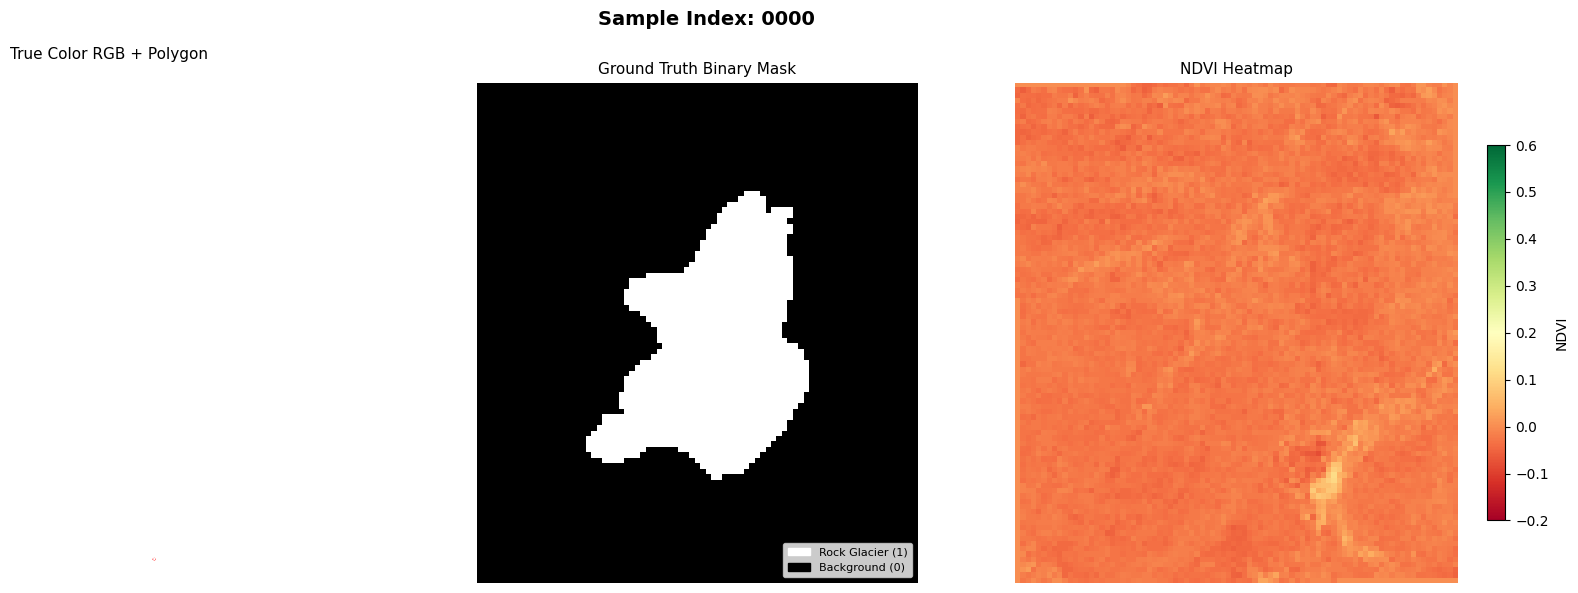

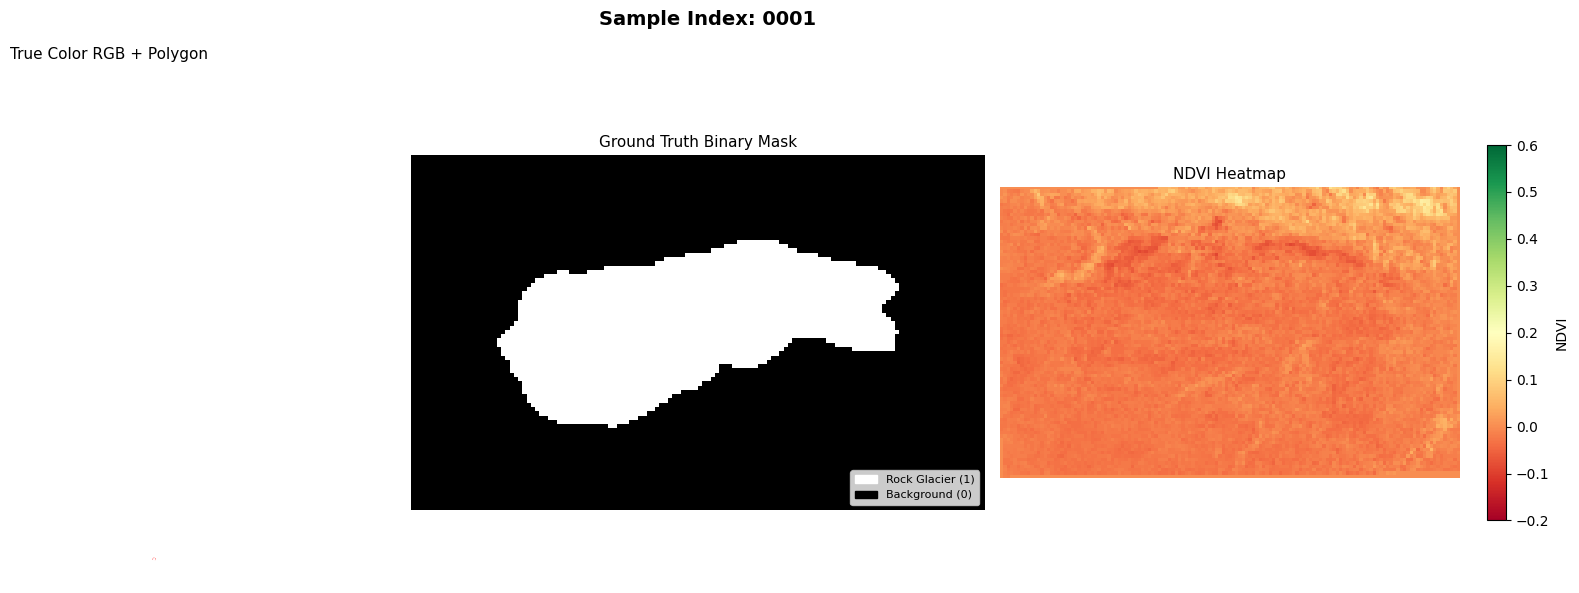

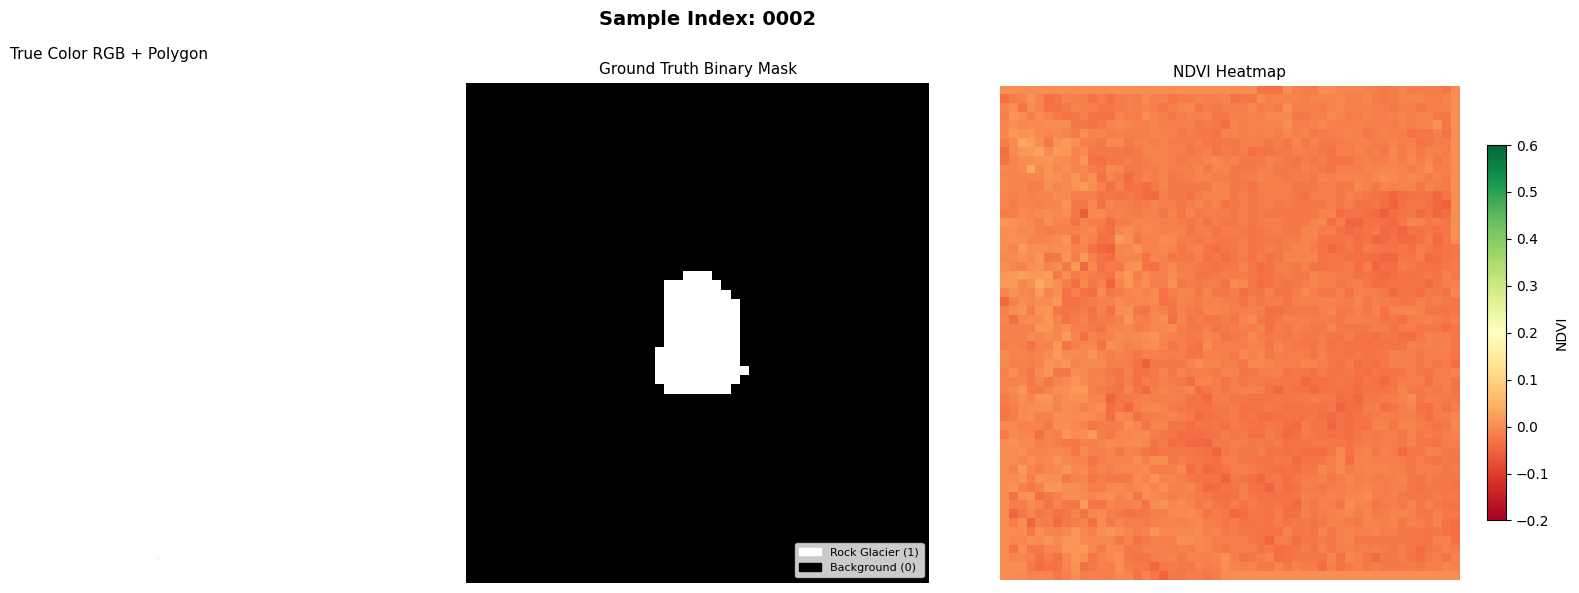

In [4]:
HEATMAP_BAND  = 7   # 1-indexed rasterio band  (7 = NDVI)
HEATMAP_LABEL = BAND_NAMES[HEATMAP_BAND]
HEATMAP_CMAP  = 'RdYlGn'
HEATMAP_VMIN  = -0.2
HEATMAP_VMAX  =  0.6

def visualize_sample(idx_str, heatmap_band=HEATMAP_BAND):
    """
    Plot a 3-panel EDA figure for tile `idx_str`.
    Panel A: True Color RGB with GeoJSON polygon overlay
    Panel B: Ground Truth Binary Mask
    Panel C: Heatmap of `heatmap_band` (default: NDVI)
    """
    f_path = os.path.join(FEATURE_DIR, f'feature_{idx_str}.tif')
    m_path = os.path.join(MASK_DIR,    f'mask_{idx_str}.tif')
    p_path = os.path.join(POLYGON_DIR, f'polygon_{int(idx_str)}.geojson')

    if not os.path.exists(f_path):
        print(f"[SKIP] Feature not found: {f_path}")
        return
    if not os.path.exists(m_path):
        print(f"[SKIP] Mask not found: {m_path}")
        return

    # ── Read data ─────────────────────────────────────────────────────────────
    with rasterio.open(f_path) as src:
        r         = src.read(3).astype(float)   # B4 Red
        g         = src.read(2).astype(float)   # B3 Green
        b         = src.read(1).astype(float)   # B2 Blue
        heatmap   = src.read(heatmap_band).astype(float)
        raster_crs = src.crs

    with rasterio.open(m_path) as src:
        mask = src.read(1)

    min_h = min(r.shape[0], mask.shape[0])
    min_w = min(r.shape[1], mask.shape[1])
    r, g, b = r[:min_h, :min_w], g[:min_h, :min_w], b[:min_h, :min_w]
    heatmap = heatmap[:min_h, :min_w]
    mask = mask[:min_h, :min_w]

    # ── Normalize RGB (clip top 2% brightness) ────────────────────────────────
    def norm_band(band):
        p2, p98 = np.percentile(band[np.isfinite(band)], [2, 98])
        return np.clip((band - p2) / (p98 - p2 + 1e-9), 0, 1)

    rgb_norm = np.dstack([norm_band(r), norm_band(g), norm_band(b)])

    # ── Mask nodata in heatmap for display ────────────────────────────────────
    heatmap_display = np.where((heatmap == -9999) | ~np.isfinite(heatmap), np.nan, heatmap)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Sample Index: {idx_str}', fontsize=14, fontweight='bold')

    # Panel A – RGB
    axes[0].imshow(rgb_norm)
    axes[0].set_title('True Color RGB (B4/B3/B2)', fontsize=11)
    axes[0].axis('off')

    if os.path.exists(p_path):
        try:
            gdf = gpd.read_file(p_path).to_crs(raster_crs)
            gdf.plot(ax=axes[0], facecolor='none', edgecolor='red', linewidth=2)
            axes[0].set_title('True Color RGB + Polygon', fontsize=11)
        except Exception as e:
            print(f"  [WARN] Could not overlay polygon for {idx_str}: {e}")

    # Panel B – Binary Mask
    axes[1].imshow(mask, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[1].set_title('Ground Truth Binary Mask', fontsize=11)
    axes[1].axis('off')
    rock_pct = 100 * mask.sum() / mask.size
    axes[1].set_xlabel(f'Rock Glacier: {rock_pct:.1f}%  |  Background: {100-rock_pct:.1f}%', fontsize=9)
    legend_patches = [
        mpatches.Patch(color='white', label='Rock Glacier (1)'),
        mpatches.Patch(color='black', label='Background (0)'),
    ]
    axes[1].legend(handles=legend_patches, loc='lower right', fontsize=8)

    # Panel C – Heatmap
    h_label = BAND_NAMES.get(heatmap_band, f'Band {heatmap_band}')
    im = axes[2].imshow(heatmap_display, cmap=HEATMAP_CMAP, vmin=HEATMAP_VMIN, vmax=HEATMAP_VMAX)
    axes[2].set_title(f'{h_label} Heatmap', fontsize=11)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], shrink=0.75, label=h_label)

    plt.tight_layout()
    plt.show()


# ── Visualize first 3 samples ─────────────────────────────────────────────────
for f in feature_files[:3]:
    visualize_sample(get_idx(f))

## 5. Data Health & NoData Assessment

Scan every feature tile for `NaN`, `±Inf`, or `-9999` sentinel values.
Files flagged here should be inspected and potentially excluded from training.

In [5]:
def check_data_quality(f_path, nodata_flag=-9999):
    """
    Read all bands and check for NaN, Inf, or nodata sentinel values.
    Returns dict with per-band and global diagnostics.
    """
    with rasterio.open(f_path) as src:
        data = src.read().astype(np.float64)   # shape: (bands, H, W)

    diagnostics = {
        'file'        : os.path.basename(f_path),
        'has_nan'     : bool(np.isnan(data).any()),
        'has_inf'     : bool(np.isinf(data).any()),
        'has_nodata'  : bool((data == nodata_flag).any()),
        'nan_pct'     : 100 * np.isnan(data).sum() / data.size,
        'nodata_pct'  : 100 * (data == nodata_flag).sum() / data.size,
    }
    return diagnostics


print("Scanning all feature tiles for data quality issues...\n")
quality_records = [check_data_quality(f) for f in feature_files]
df_quality = pd.DataFrame(quality_records)

# ── Summary counts ────────────────────────────────────────────────────────────
nan_count     = df_quality['has_nan'].sum()
inf_count     = df_quality['has_inf'].sum()
nodata_count  = df_quality['has_nodata'].sum()
clean_count   = (~df_quality[['has_nan', 'has_inf', 'has_nodata']].any(axis=1)).sum()

print(f"➡ Clean files (no issues)      : {clean_count}")
print(f"➡ Files with NaN values        : {nan_count}")
print(f"➡ Files with Infinite values   : {inf_count}")
print(f"➡ Files with -9999 (NoData)    : {nodata_count}")

# ── Show problematic files ────────────────────────────────────────────────────
problematic = df_quality[
    df_quality['has_nan'] | df_quality['has_inf'] | df_quality['has_nodata']
].reset_index(drop=True)

if not problematic.empty:
    print("\n⚠️  Problematic files (recommend inspection / exclusion):")
    display(problematic[['file', 'has_nan', 'has_inf', 'has_nodata', 'nan_pct', 'nodata_pct']])
else:
    print("\n✅  No data-quality issues found across the full dataset.")

Scanning all feature tiles for data quality issues...

➡ Clean files (no issues)      : 607
➡ Files with NaN values        : 0
➡ Files with Infinite values   : 0
➡ Files with -9999 (NoData)    : 0

✅  No data-quality issues found across the full dataset.


## 6. Per-Band Statistics

Compute global min / max / mean / std for all 12 bands — useful for deciding normalisation strategy (per-band z-score vs. global min-max).

In [6]:
N_BANDS     = 12
SAMPLE_LIMIT = 50    # cap for speed — set to None to use full dataset

sample_files = feature_files[:SAMPLE_LIMIT] if SAMPLE_LIMIT else feature_files

band_pixels = {b: [] for b in range(1, N_BANDS + 1)}

for f_path in sample_files:
    with rasterio.open(f_path) as src:
        for b in range(1, N_BANDS + 1):
            arr = src.read(b).astype(np.float32).flatten()
            valid = arr[(arr != -9999) & np.isfinite(arr)]
            band_pixels[b].extend(valid.tolist())

stats_records = []
for b in range(1, N_BANDS + 1):
    vals = np.array(band_pixels[b])
    stats_records.append({
        'band'  : b,
        'name'  : BAND_NAMES[b],
        'min'   : vals.min(),
        'max'   : vals.max(),
        'mean'  : vals.mean(),
        'std'   : vals.std(),
        'p5'    : np.percentile(vals, 5),
        'p95'   : np.percentile(vals, 95),
    })

df_stats = pd.DataFrame(stats_records).set_index('band')
print(f"Per-Band Statistics (sampled from {len(sample_files)} tiles):\n")
display(df_stats.round(4))

Per-Band Statistics (sampled from 50 tiles):



,name,min,max,mean,std,p5,p95
band,,,,,,,
1,B2 (Blue),0.0342,1.0108,0.2902,0.1748,0.1088,0.6385
2,B3 (Green),0.0497,0.9814,0.3038,0.1619,0.1299,0.6245
3,B4 (Red),0.0649,0.9576,0.3145,0.1528,0.1522,0.6198
4,B8 (NIR),0.0976,0.8865,0.3347,0.1261,0.2055,0.5964
5,B11 (SWIR-1),0.0603,0.4996,0.2761,0.0492,0.1935,0.3477
6,B12 (SWIR-2),0.0644,0.4637,0.2518,0.0434,0.1818,0.3202
7,NDVI,-0.2525,0.5095,0.0523,0.0760,-0.0286,0.1987
8,NDWI,-0.5650,0.3116,-0.0799,0.1000,-0.2638,0.0345
9,NDSI,-0.6708,0.8516,-0.0115,0.2808,-0.3916,0.4613


## 7. Class Separability Analysis

Pixel-level KDE plots comparing feature distributions for **Rock Glacier (Class 1)** vs **Background (Class 0)**.
Good separation → that feature is highly discriminative for the segmentation model.

[SKIP] Shape mismatch for idx=0000: feature=(95, 84) mask=(92, 81)
[SKIP] Shape mismatch for idx=0001: feature=(87, 137) mask=(83, 134)
[SKIP] Shape mismatch for idx=0002: feature=(56, 52) mask=(53, 49)
[SKIP] Shape mismatch for idx=0003: feature=(74, 76) mask=(72, 73)
[SKIP] Shape mismatch for idx=0004: feature=(140, 137) mask=(136, 133)
[SKIP] Shape mismatch for idx=0005: feature=(77, 127) mask=(72, 124)
[SKIP] Shape mismatch for idx=0006: feature=(109, 118) mask=(105, 114)
[SKIP] Shape mismatch for idx=0007: feature=(84, 107) mask=(81, 104)
[SKIP] Shape mismatch for idx=0008: feature=(69, 59) mask=(67, 56)
[SKIP] Shape mismatch for idx=0009: feature=(71, 67) mask=(68, 64)
[SKIP] Shape mismatch for idx=0010: feature=(66, 60) mask=(63, 57)
[SKIP] Shape mismatch for idx=0011: feature=(95, 67) mask=(92, 64)
[SKIP] Shape mismatch for idx=0012: feature=(92, 89) mask=(89, 85)
[SKIP] Shape mismatch for idx=0013: feature=(103, 117) mask=(99, 114)
[SKIP] Shape mismatch for idx=0014: feature=(

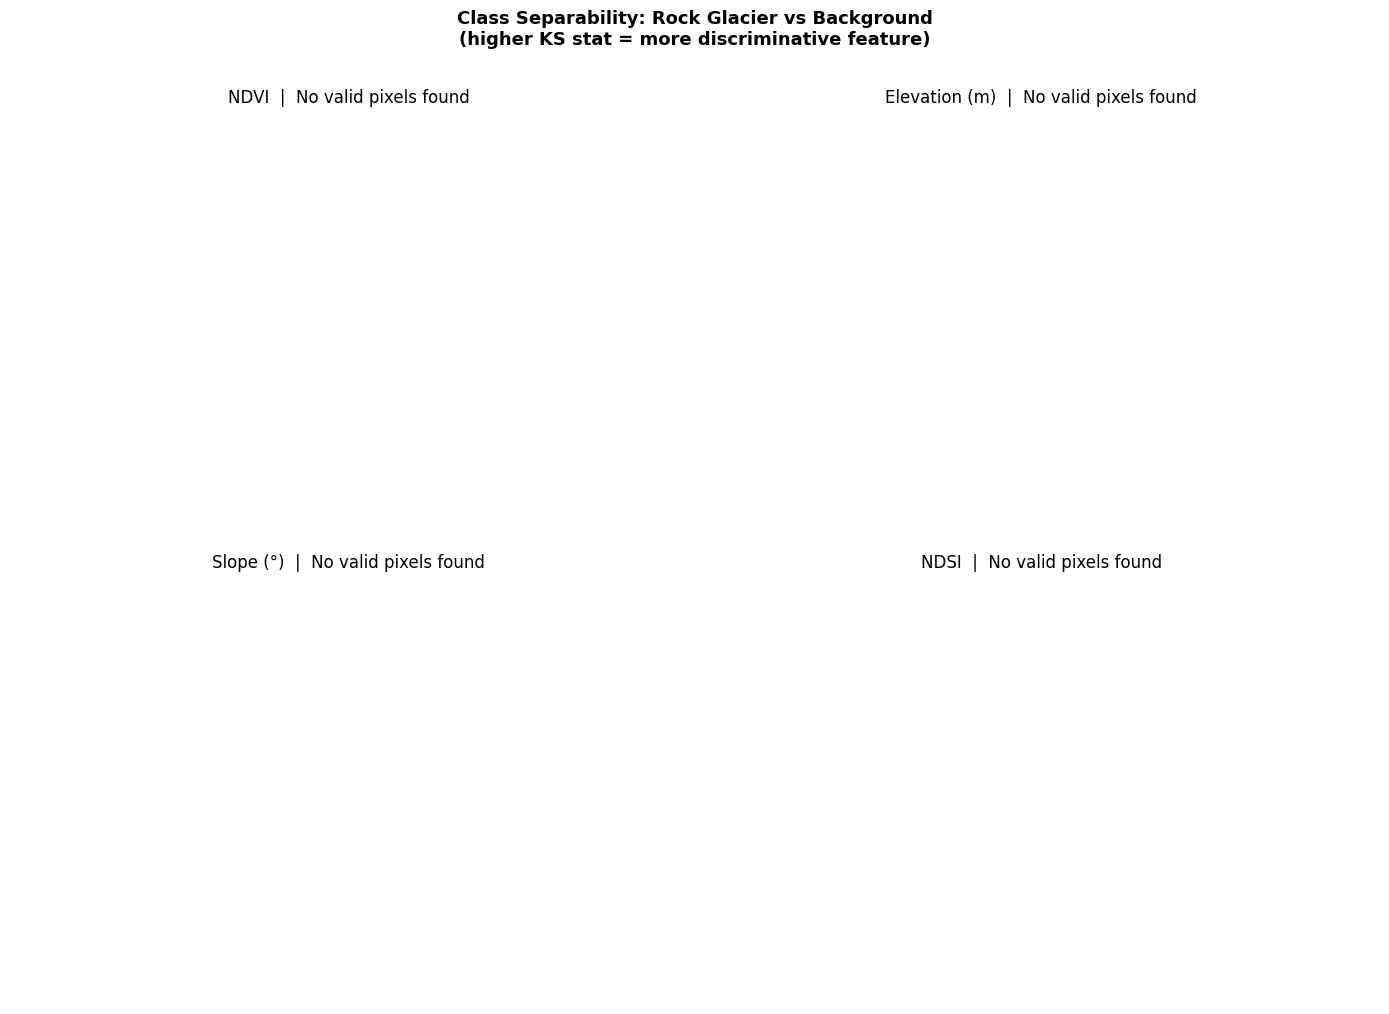


Kolmogorov-Smirnov Statistics (0→1, higher is better separation):
  Band  7 (NDVI              ): skipped (no valid pixels)
  Band 10 (Elevation (m)     ): skipped (no valid pixels)
  Band 11 (Slope (°)         ): skipped (no valid pixels)
  Band  9 (NDSI              ): skipped (no valid pixels)


In [7]:
# Bands to compare (1-indexed)
COMPARE_BANDS = [7, 10, 11, 9]   # NDVI, Elevation, Slope, NDSI
MAX_SAMPLES   = 20               # number of tiles to sample (memory control)

pixel_data = {b: {'rock': [], 'bg': []} for b in COMPARE_BANDS}

for f_path in feature_files[:MAX_SAMPLES]:
    idx    = get_idx(f_path)
    m_path = mask_lookup.get(idx)
    if m_path is None:
        continue

    with rasterio.open(f_path) as f_src, rasterio.open(m_path) as m_src:
        # ── Guard: skip pairs whose pixel grids don't match ──────────────────
        min_h = min(f_src.shape[0], m_src.shape[0])
        min_w = min(f_src.shape[1], m_src.shape[1])

        mask_flat = m_src.read(1)[:min_h, :min_w].flatten()

        for b in COMPARE_BANDS:
            arr   = f_src.read(b)[:min_h, :min_w].astype(np.float32).flatten()
            valid = (arr != -9999) & np.isfinite(arr)
            pixel_data[b]['rock'].extend(arr[valid & (mask_flat == 1)].tolist())
            pixel_data[b]['bg'  ].extend(arr[valid & (mask_flat == 0)].tolist())

# ── KDE Plots ─────────────────────────────────────────────────────────────────
n_cols = 2
n_rows = int(np.ceil(len(COMPARE_BANDS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, b in enumerate(COMPARE_BANDS):
    ax = axes[i]
    rock_arr = np.array(pixel_data[b]['rock'])
    bg_arr   = np.array(pixel_data[b]['bg'])

    if len(rock_arr) == 0 or len(bg_arr) == 0:
        ax.set_title(f'{BAND_NAMES[b]}  |  No valid pixels found')
        ax.axis('off')
        continue

    # Clip extreme outliers for readability
    p1, p99  = np.percentile(np.concatenate([rock_arr, bg_arr]), [1, 99])
    rock_arr = rock_arr[(rock_arr >= p1) & (rock_arr <= p99)]
    bg_arr   = bg_arr  [(bg_arr   >= p1) & (bg_arr   <= p99)]

    sns.kdeplot(rock_arr, fill=True, color='tomato',    label=f'Rock Glacier (n={len(rock_arr):,})', ax=ax, alpha=0.6)
    sns.kdeplot(bg_arr,   fill=True, color='steelblue', label=f'Background  (n={len(bg_arr):,})',   ax=ax, alpha=0.6)

    ks_stat, _ = stats.ks_2samp(rock_arr[:5000], bg_arr[:5000])
    ax.set_title(f'{BAND_NAMES[b]}  |  KS stat = {ks_stat:.3f}', fontsize=11)
    ax.set_xlabel(BAND_NAMES[b])
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(COMPARE_BANDS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Class Separability: Rock Glacier vs Background\n(higher KS stat = more discriminative feature)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nKolmogorov-Smirnov Statistics (0→1, higher is better separation):")
for b in COMPARE_BANDS:
    rock_arr = np.array(pixel_data[b]['rock'])[:5000]
    bg_arr   = np.array(pixel_data[b]['bg'])[:5000]
    if len(rock_arr) == 0 or len(bg_arr) == 0:
        print(f"  Band {b:>2} ({BAND_NAMES[b]:<18}): skipped (no valid pixels)")
        continue
    ks, _ = stats.ks_2samp(rock_arr, bg_arr)
    print(f"  Band {b:>2} ({BAND_NAMES[b]:<18}): KS = {ks:.4f}")

## 8. Class Imbalance Calculation & Loss Recommendation

Global pixel-level class ratio across the **entire** mask dataset.

       GLOBAL CLASS IMBALANCE REPORT
  Rock Glacier pixels (Class 1) :      890,744  (18.31%)
  Background pixels   (Class 0) :    3,974,590  (81.69%)
  Imbalance ratio  (BG / Rock)  : 4.5:1

📋  Training Recommendation:
  🟢 ACCEPTABLE balance (>15% positive pixels).
     → Standard BCE Loss is viable; Focal/Dice may still improve boundary precision.


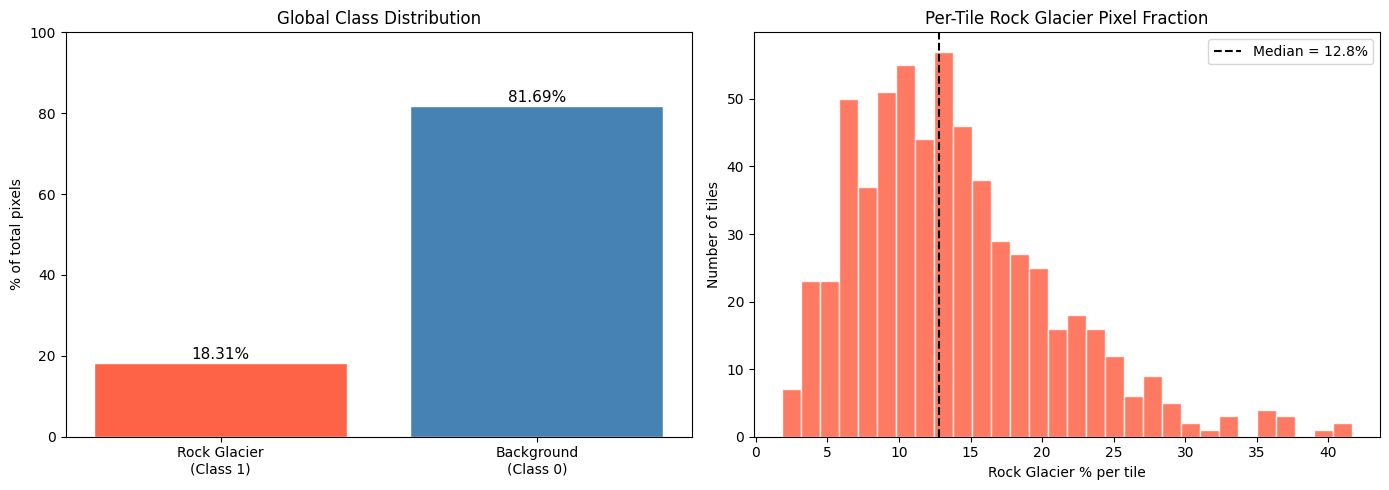

In [8]:
total_rock_pixels = 0
total_bg_pixels   = 0
per_tile_ratios   = []

for m_path in mask_files:
    with rasterio.open(m_path) as src:
        mask = src.read(1)
    n_rock = int(np.sum(mask == 1))
    n_bg   = int(np.sum(mask == 0))
    total_rock_pixels += n_rock
    total_bg_pixels   += n_bg
    total = n_rock + n_bg
    per_tile_ratios.append(100 * n_rock / total if total > 0 else 0)

overall_total = total_rock_pixels + total_bg_pixels
rock_ratio    = 100 * total_rock_pixels / overall_total if overall_total > 0 else 0
bg_ratio      = 100 * total_bg_pixels   / overall_total if overall_total > 0 else 0
imbalance_ratio = total_bg_pixels / total_rock_pixels if total_rock_pixels > 0 else float('inf')

print("=" * 55)
print("       GLOBAL CLASS IMBALANCE REPORT")
print("=" * 55)
print(f"  Rock Glacier pixels (Class 1) : {total_rock_pixels:>12,}  ({rock_ratio:.2f}%)")
print(f"  Background pixels   (Class 0) : {total_bg_pixels:>12,}  ({bg_ratio:.2f}%)")
print(f"  Imbalance ratio  (BG / Rock)  : {imbalance_ratio:.1f}:1")
print("=" * 55)

# ── Recommendation ────────────────────────────────────────────────────────────
print("\n📋  Training Recommendation:")
if rock_ratio < 5:
    print("  🔴 SEVERE imbalance (<5% positive pixels).")
    print("     → Use Focal Loss (γ=2–4) + Dice Loss combined (e.g. 0.5/0.5).")
    print("     → Consider patch-level oversampling: oversample tiles where mask=1.")
    print("     → Set pos_weight in BCEWithLogitsLoss to imbalance_ratio as fallback.")
elif rock_ratio < 15:
    print("  🟠 MODERATE imbalance (<15% positive pixels).")
    print("     → Focal Loss (γ=2) OR Dice Loss is recommended.")
    print("     → Standard BCE Loss will under-predict rock glaciers.")
else:
    print("  🟢 ACCEPTABLE balance (>15% positive pixels).")
    print("     → Standard BCE Loss is viable; Focal/Dice may still improve boundary precision.")

# ── Histogram of per-tile rock glacier % ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Rock Glacier\n(Class 1)', 'Background\n(Class 0)'],
            [rock_ratio, bg_ratio], color=['tomato', 'steelblue'], edgecolor='white')
axes[0].set_ylabel('% of total pixels')
axes[0].set_title('Global Class Distribution')
axes[0].set_ylim(0, 100)
for rect, val in zip(axes[0].patches, [rock_ratio, bg_ratio]):
    axes[0].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontsize=11)

axes[1].hist(per_tile_ratios, bins=30, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(np.median(per_tile_ratios), color='black', linestyle='--',
                label=f'Median = {np.median(per_tile_ratios):.1f}%')
axes[1].set_xlabel('Rock Glacier % per tile')
axes[1].set_ylabel('Number of tiles')
axes[1].set_title('Per-Tile Rock Glacier Pixel Fraction')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Inter-Band Correlation Heatmap

Pearson correlation between all 12 bands — helps identify redundant features (e.g. B11/B12 are often highly correlated) and informs potential feature reduction or ablation strategies.

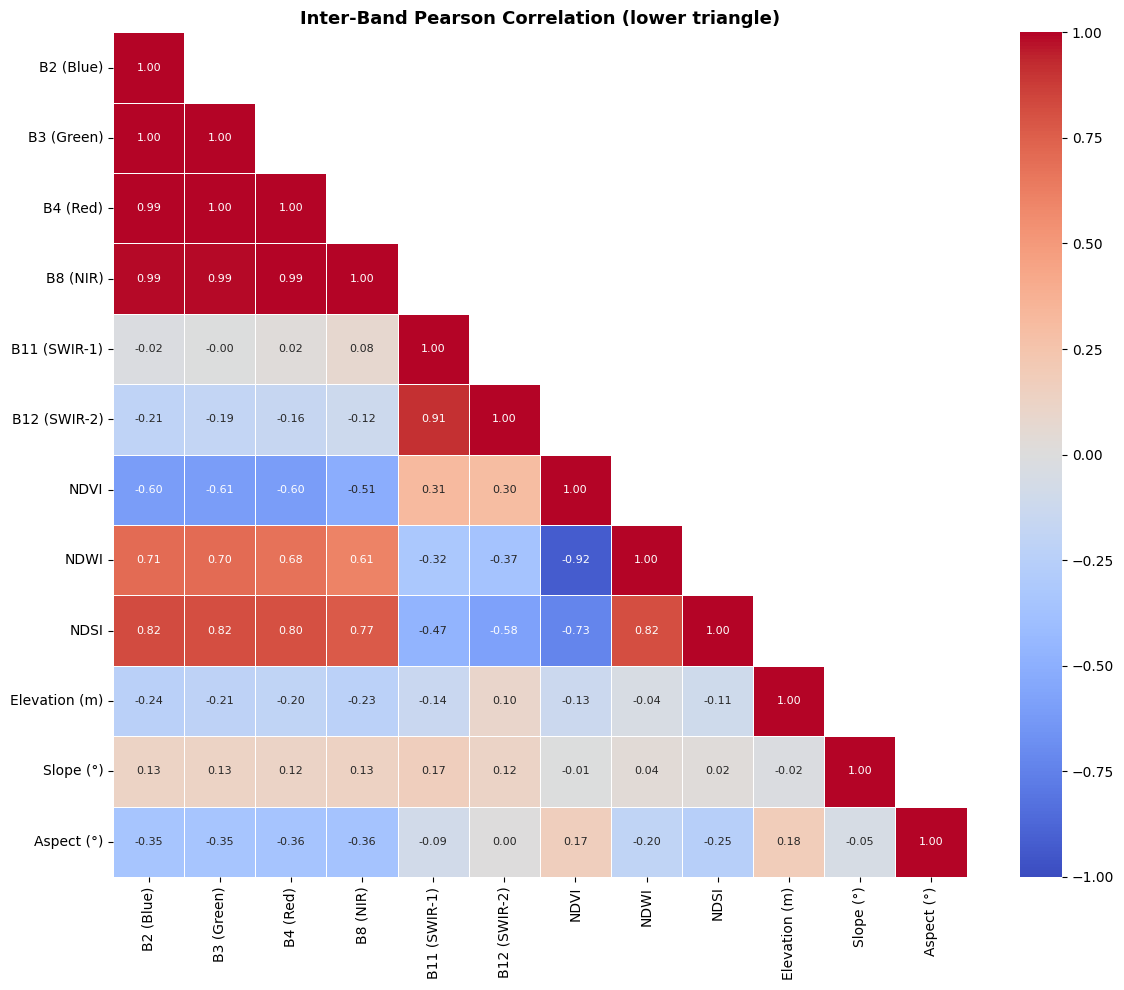

In [9]:
CORR_SAMPLE   = 10    # number of tiles
MAX_PIXELS    = 5000  # pixels per tile to keep memory low

pixel_matrix = []

for f_path in feature_files[:CORR_SAMPLE]:
    with rasterio.open(f_path) as src:
        bands = [src.read(b).astype(np.float32).flatten() for b in range(1, N_BANDS + 1)]

    tile_mat = np.stack(bands, axis=1)  # shape: (H*W, 12)
    # Filter out rows with nodata / nan in any band
    valid_mask = np.all((tile_mat != -9999) & np.isfinite(tile_mat), axis=1)
    tile_mat   = tile_mat[valid_mask]
    if len(tile_mat) > MAX_PIXELS:
        tile_mat = tile_mat[np.random.choice(len(tile_mat), MAX_PIXELS, replace=False)]
    pixel_matrix.append(tile_mat)

all_pixels = np.vstack(pixel_matrix)   # shape: (N, 12)
corr_matrix = np.corrcoef(all_pixels.T)

df_corr = pd.DataFrame(corr_matrix,
                        index  =[BAND_NAMES[b] for b in range(1, N_BANDS + 1)],
                        columns=[BAND_NAMES[b] for b in range(1, N_BANDS + 1)])

fig, ax = plt.subplots(figsize=(12, 10))
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(df_corr, mask=mask_tri, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Inter-Band Pearson Correlation (lower triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. EDA Summary & Pre-Training Checklist

Final readiness check before building the PyTorch `Dataset`.

In [10]:
# Re-compute flags from previous cells
has_mismatches   = len(mismatches) > 0
has_missing      = len(missing_masks) > 0
has_quality_flag = not problematic.empty if 'problematic' in dir() else False

print("╔══════════════════════════════════════════════════════╗")
print("║         PRE-TRAINING EDA CHECKLIST                  ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'✅' if not has_mismatches else '❌'}  Spatial alignment (shape/CRS/transform)      ║")
print(f"║  {'✅' if not has_missing   else '❌'}  No missing mask files                         ║")
print(f"║  {'✅' if not has_quality_flag else '⚠️ '}  No NaN / Inf / NoData in feature tiles      ║")
print(f"║  {'✅' if rock_ratio > 0    else '❌'}  Class imbalance quantified                    ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Total valid pairs  : {aligned_count:<30} ║")
print(f"║  Rock Glacier ratio : {rock_ratio:.2f}%{'':<27} ║")
print(f"║  Imbalance ratio    : {imbalance_ratio:.1f}:1 (BG:Rock){'':<19} ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  RECOMMENDED LOSS FUNCTIONS:                        ║")
if rock_ratio < 5:
    print("║  → Focal Loss (γ=2–4) + Dice Loss (0.5/0.5)        ║")
elif rock_ratio < 15:
    print("║  → Focal Loss (γ=2) or Dice Loss                    ║")
else:
    print("║  → BCE Loss viable; Focal/Dice for better boundaries║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║         PRE-TRAINING EDA CHECKLIST                  ║
╠══════════════════════════════════════════════════════╣
║  ❌  Spatial alignment (shape/CRS/transform)      ║
║  ✅  No missing mask files                         ║
║  ✅  No NaN / Inf / NoData in feature tiles      ║
║  ✅  Class imbalance quantified                    ║
╠══════════════════════════════════════════════════════╣
║  Total valid pairs  : 0                              ║
║  Rock Glacier ratio : 18.31%                            ║
║  Imbalance ratio    : 4.5:1 (BG:Rock)                    ║
╠══════════════════════════════════════════════════════╣
║  RECOMMENDED LOSS FUNCTIONS:                        ║
║  → BCE Loss viable; Focal/Dice for better boundaries║
╚══════════════════════════════════════════════════════╝
